# **Klasifikasi Jenis Tanah Menggunakan SVM Berbasis Multi-Fitur (HSV, GLCM, LBP,) dengan PCA**

Dataset:
Aluvial, Andosol, Entisol, Humus, Inceptisol, Kapur, Laterit, Pasir

Pendekatan:
- Warna   : HSV (mean, std)
- Tekstur : GLCM + LBP
- Reduksi dimensi : PCA
- Model   : SVM (RBF) + GridSearchCV

Tujuan:
Membangun model klasifikasi citra tanah yang robust dan dapat dijelaskan secara analitis.

## Mount Google Drive
Dataset disimpan di Google Drive untuk kemudahan akses pada Google Colab.

In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Library
Library utama untuk pengolahan citra, ekstraksi fitur, dan machine learning.

In [60]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.measure import shannon_entropy

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pandas as pd

# supaya plot konsisten
plt.rcParams['figure.figsize'] = (6,4)
sns.set_style("whitegrid")

## Load Dataset
Struktur dataset harus berbentuk folder per kelas.

In [61]:
base_path = "/content/drive/MyDrive/Computer Vision/UTS ComVis 2318101/Dataset Tanah"

data = []

for label in sorted(os.listdir(base_path)):
    folder = os.path.join(base_path, label)
    if not os.path.isdir(folder):
        continue

    for file in os.listdir(folder):
        if file.lower().endswith(('.jpg','.jpeg','.png')):
            data.append([os.path.join(folder, file), label])

print("Total data:", len(data))
print("Contoh:", data[:3])

Total data: 400
Contoh: [['/content/drive/MyDrive/Computer Vision/UTS ComVis 2318101/Dataset Tanah/Aluvial/aluvial-001.jpg', 'Aluvial'], ['/content/drive/MyDrive/Computer Vision/UTS ComVis 2318101/Dataset Tanah/Aluvial/aluvial-016.jpg', 'Aluvial'], ['/content/drive/MyDrive/Computer Vision/UTS ComVis 2318101/Dataset Tanah/Aluvial/aluvial-008.jpg', 'Aluvial']]


## Visualisasi Dataset
Menampilkan contoh citra dari beberapa kelas.

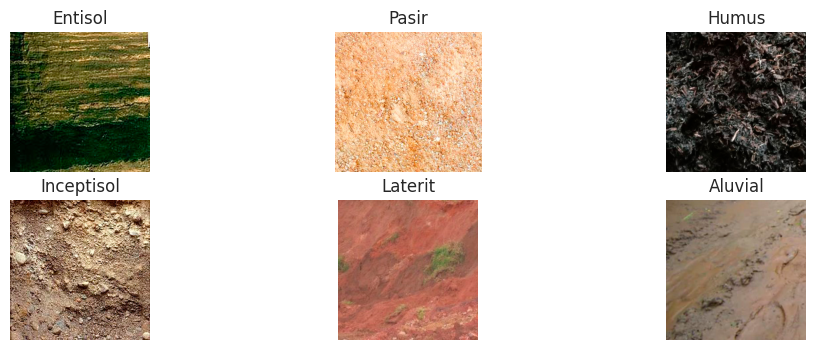

In [15]:
plt.figure(figsize=(12,4))

classes = list(set([d[1] for d in data]))

for i, cls in enumerate(classes[:6]):
    for item in data:
        if item[1] == cls:
            img = cv2.imread(item[0])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(2,3,i+1)
            plt.imshow(img)
            plt.title(cls)
            plt.axis('off')
            break

plt.show()

## Preprocessing
- Resize 256x256
- Crop tengah (fokus tekstur)
- Grayscale
- Gaussian Blur (reduksi noise)

In [35]:
processed = []

for path, label in data:
    img = cv2.imread(path)
    if img is None:
        continue

    img = cv2.resize(img, (256,256))

    h, w = img.shape[:2]
    crop = img[h//6:5*h//6, w//6:5*w//6]

    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3,3), 0)

    processed.append((label, crop, gray))

print("Processed:", len(processed))

Processed: 400


## Visualisasi Preprocessing

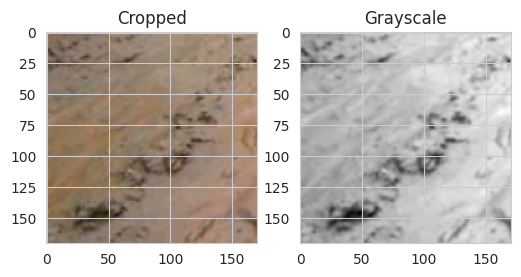

In [36]:
label, img, gray = processed[0]

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Cropped")

plt.subplot(1,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")

plt.show()

## Train-Test Split (Anti Data Leakage)

In [37]:
labels = [p[0] for p in processed]

train_data, test_data = train_test_split(
    processed,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Train:", len(train_data), "Test:", len(test_data))

Train: 320 Test: 80


## Augmentasi Data
Rotasi 90°, 180°, 270° untuk memperkaya data training.

In [38]:
def rotate(img, angle):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    return cv2.warpAffine(img, M, (w, h))

aug_train = []

for label, img, gray in train_data:
    aug_train.append((label, img, gray))

    # ROTASI
    for angle in [90, 180, 270]:
        rot = rotate(img, angle)
        gray_r = cv2.cvtColor(rot, cv2.COLOR_BGR2GRAY)
        gray_r = cv2.GaussianBlur(gray_r, (3,3), 0)
        aug_train.append((label, rot, gray_r))

    # FLIP
    flip = cv2.flip(img, 1)
    gray_f = cv2.cvtColor(flip, cv2.COLOR_BGR2GRAY)
    gray_f = cv2.GaussianBlur(gray_f, (3,3), 0)
    aug_train.append((label, flip, gray_f))

print("Augmented:", len(aug_train))

Augmented: 1600


## Ekstraksi Fitur
Menggunakan:
- HSV => warna
- GLCM => tekstur global
- LBP => tekstur lokal

In [39]:
def extract_hsv(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    feats = []
    for i in range(3):
        ch = hsv[:,:,i]
        feats.append(ch.mean())
        feats.append(ch.std())
    return np.array(feats)

In [40]:
def extract_glcm(gray):
    gray_q = (gray // 8).astype(np.uint8)

    glcm = graycomatrix(
        gray_q,
        distances=[1,2],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=32,
        symmetric=True,
        normed=True
    )

    feats = []
    for p in ['contrast','homogeneity','energy','correlation']:
        vals = graycoprops(glcm, p)
        feats.append(vals.mean())
        feats.append(vals.std())

    return np.array(feats)

In [41]:
def extract_lbp(gray):
    lbp = local_binary_pattern(gray, 16, 2, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=18, range=(0,18))
    hist = hist.astype(float)
    hist /= (hist.sum() + 1e-6)
    return hist

## Build Feature Matrix
Menggabungkan seluruh fitur dengan pembobotan.

In [42]:
def build_dataset(dataset):
    X, y = [], []

    for label, img, gray in dataset:
        features = np.concatenate([
            extract_glcm(gray)*2.5,
            extract_lbp(gray)*2.0,
            extract_stat(gray)*1.2,
            extract_hsv(img)*0.8
        ])

        X.append(features)
        y.append(label)

    return np.vstack(X), np.array(y)

X_train, y_train = build_dataset(aug_train)
X_test, y_test = build_dataset(test_data)

print("Train shape:", X_train.shape)

Train shape: (1600, 37)


In [45]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## PCA
Mengurangi dimensi fitur agar SVM lebih optimal.

In [48]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Explained variance:", np.sum(pca.explained_variance_ratio_))

Explained variance: 0.9530874129332207


## Visualisasi PCA
Menampilkan distribusi data dalam 2 dimensi setelah reduksi dimensi.

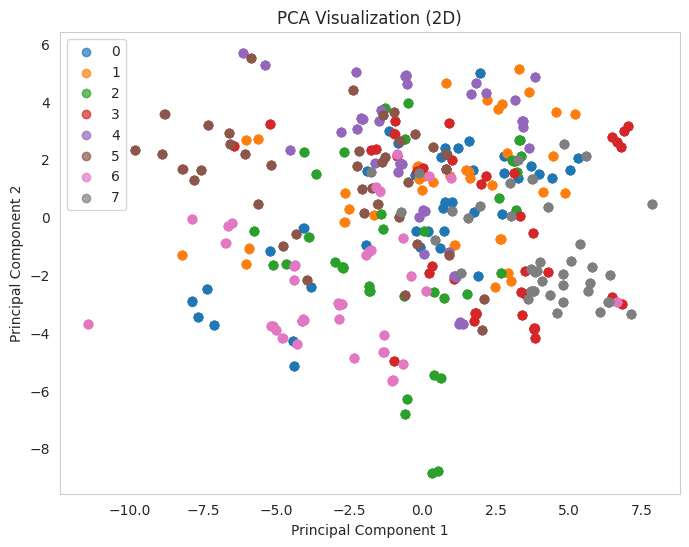

In [54]:
from sklearn.decomposition import PCA

# PCA khusus visualisasi 2D
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_train_scaled)

plt.figure(figsize=(8,6))

for i, label in enumerate(np.unique(y_train)):
    plt.scatter(
        X_vis[y_train == label, 0],
        X_vis[y_train == label, 1],
        label=le.inverse_transform([label])[0],
        alpha=0.7
    )

plt.title("PCA Visualization (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()
plt.show()

## Model

In [49]:
param_grid = {
    'C':[1,10,50],
    'gamma':['scale',0.01,0.001],
    'kernel':['rbf']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1)
grid.fit(X_train_pca, y_train)

print("Best params:", grid.best_params_)

Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [51]:
model = grid.best_estimator_

y_pred = model.predict(X_test_pca)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.925
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       0.80      0.80      0.80        10
           2       0.91      1.00      0.95        10
           3       1.00      1.00      1.00        10
           4       1.00      0.90      0.95        10
           5       0.90      0.90      0.90        10
           6       1.00      1.00      1.00        10
           7       0.89      0.80      0.84        10

    accuracy                           0.93        80
   macro avg       0.93      0.93      0.92        80
weighted avg       0.93      0.93      0.92        80



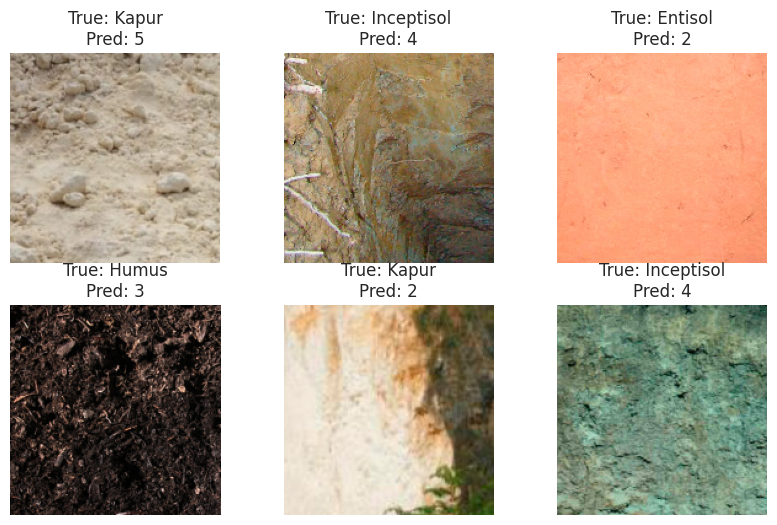

In [52]:
plt.figure(figsize=(10,6))

for i in range(6):
    label, img, gray = test_data[i]
    pred = le.inverse_transform([y_pred[i]])[0]

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img_rgb)
    plt.title(f"True: {label}\nPred: {pred}")
    plt.axis('off')

plt.show()

## Confusion Matrix
Digunakan untuk melihat performa model dalam mengklasifikasikan setiap kelas.

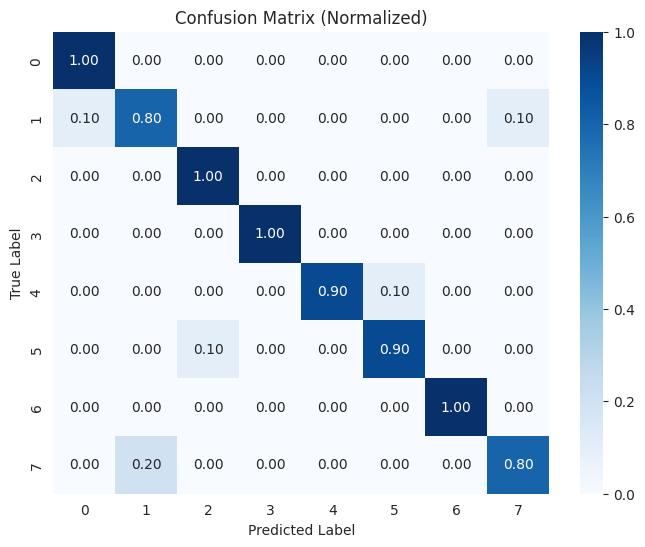

In [53]:
cm = confusion_matrix(y_test, y_pred)

# Normalisasi (persentase)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [72]:
save_path = "/content/drive/MyDrive/Computer Vision/UTS ComVis 2318101/hasil_tanah.csv"

y_true = le.inverse_transform(y_test)
y_pred_lbl = le.inverse_transform(y_pred)

try:
    conf = model.predict_proba(X_test_pca).max(axis=1)
except:
    conf = model.decision_function(X_test_pca)
    conf = (conf.max(axis=1) - conf.min()) / (conf.max() - conf.min())

df = pd.DataFrame({
    "Image_Path": [x[0] for x in test_data],
    "Actual": y_true,
    "Predicted": y_pred_lbl,
    "Confidence": conf,
    "Correct": y_true == y_pred_lbl
})

df_feat = pd.DataFrame(X_test, columns=[f"F{i+1}" for i in range(X_test.shape[1])])
df_final = pd.concat([df, df_feat], axis=1)

df_final.to_csv(save_path, index=False)

print(save_path)

/content/drive/MyDrive/Computer Vision/UTS ComVis 2318101/hasil_tanah.csv
